In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("../data/tanzania.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16


In [3]:
df["Country"] = "Tanzania"

In [4]:
df = df.replace(-999, np.nan)
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
dtype: int64

In [5]:
df["DATE"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

In [6]:
df["Month"] = df["DATE"].dt.month

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


In [9]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100
missing_percent.sort_values(ascending=False)

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
DATE           0.0
Month          0.0
dtype: float64

In [10]:
cols = ["T2M", "T2M_MAX", "T2M_MIN",
        "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(stats.zscore(df[cols], nan_policy='omit'))
outliers = (z_scores > 3)

outliers.sum()

np.int64(102)

In [11]:
df = df.ffill()
df = df.dropna()

In [12]:
df.to_csv("../data/tanzania_clean.csv", index=False)

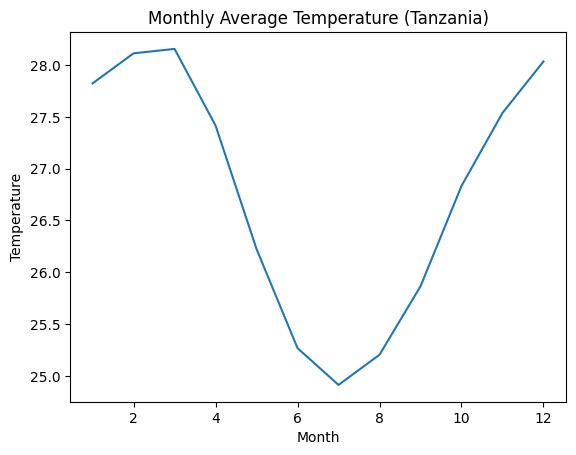

In [13]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.plot(monthly_temp.index, monthly_temp.values)
plt.title("Monthly Average Temperature (Tanzania)")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.show()

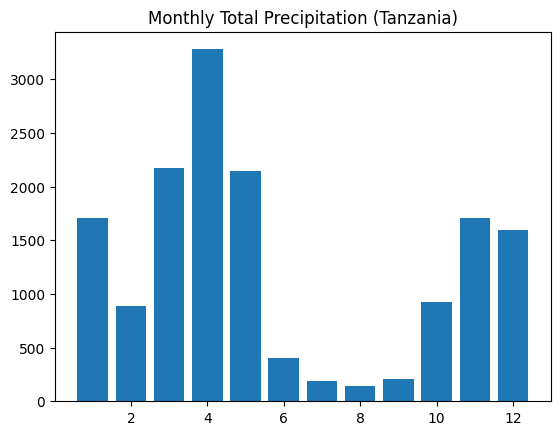

In [14]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.bar(monthly_rain.index, monthly_rain.values)
plt.title("Monthly Total Precipitation (Tanzania)")
plt.show()

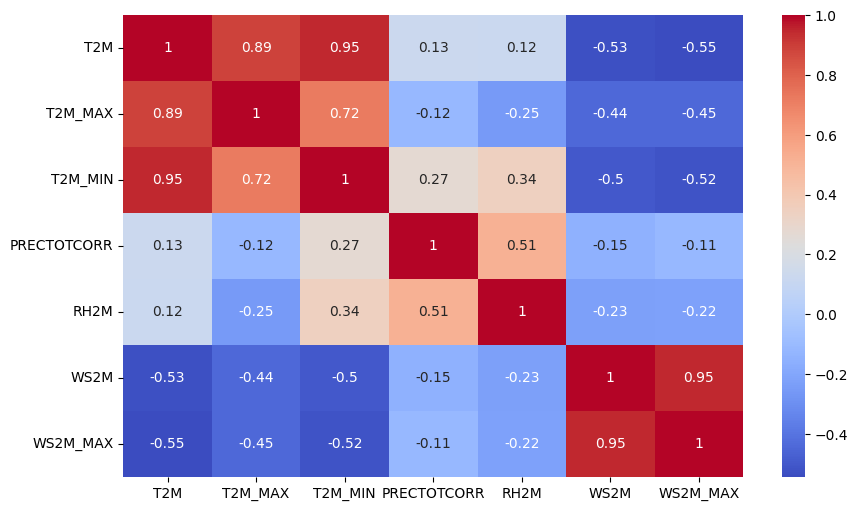

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.show()

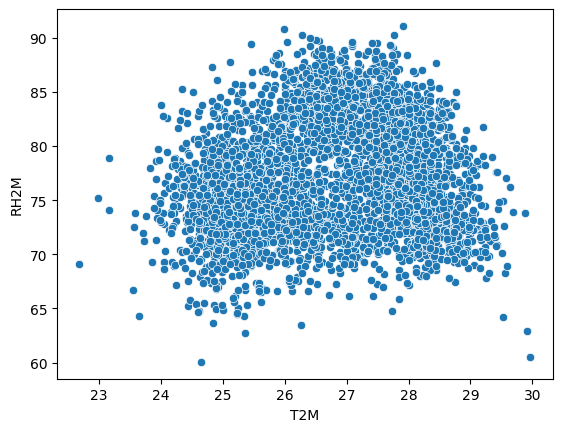

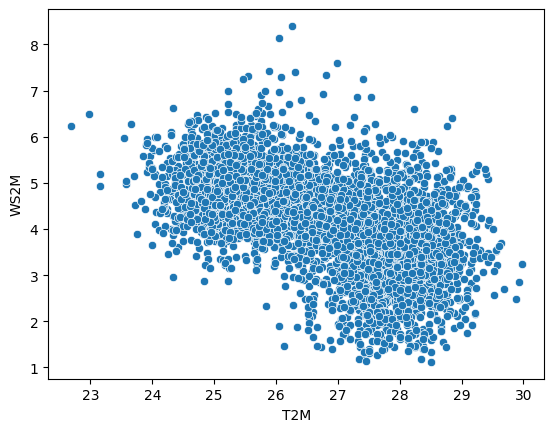

In [16]:
sns.scatterplot(data=df, x="T2M", y="RH2M")
plt.show()

sns.scatterplot(data=df, x="T2M", y="WS2M")
plt.show()

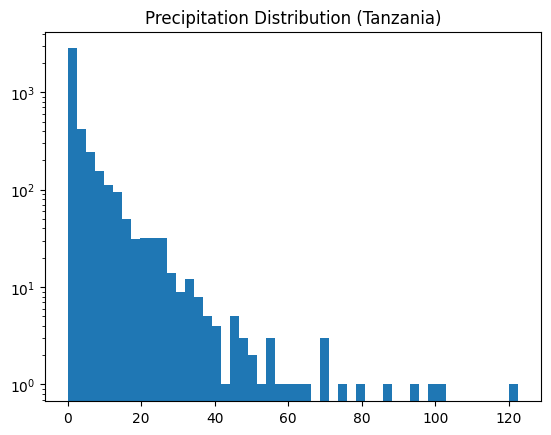

In [17]:
plt.hist(df["PRECTOTCORR"], bins=50)
plt.yscale("log")
plt.title("Precipitation Distribution (Tanzania)")
plt.show()

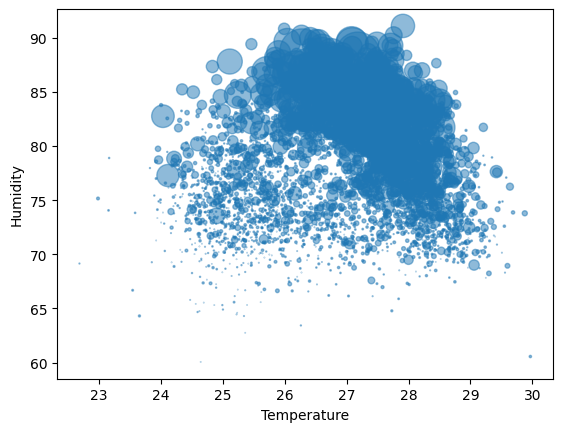

In [18]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*10, alpha=0.5)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.show()

In [19]:
from scipy import stats
import numpy as np

In [20]:
cols = ["T2M", "T2M_MAX", "T2M_MIN",
        "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(stats.zscore(df[cols], nan_policy='omit'))

In [21]:
outliers = (z_scores > 3)
outlier_count = outliers.sum()

outlier_count

np.int64(102)

We detected X outlier values using Z-score threshold (>3).
These represent extreme climate events such as heatwaves, heavy rainfall, or strong wind conditions.
We retained them because they are meaningful for climate analysis rather than data errors.

missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100
missing_percent = missing_percent.sort_values(ascending=False)

missing_percent

In [22]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100
missing_percent = missing_percent.sort_values(ascending=False)

missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
DATE           0.0
Month          0.0
dtype: float64

In [23]:
missing_percent[missing_percent > 5]

Series([], dtype: float64)

Columns with more than 5% missing values may indicate:
- Sensor gaps in satellite measurements
- Weather model estimation limitations
- Regional data sparsity

These missing values were handled using forward-fill or row removal depending on severity.

The monthly temperature trend shows clear seasonal variation.
Warmest months indicate dry/hot seasons, while cooler months align with rainy periods.

Rainfall is highly seasonal with distinct wet and dry periods.
Peak rainfall months represent monsoon or heavy precipitation seasons.

Temperature shows strong negative correlation with humidity.
Wind speed has weak but noticeable relationships with precipitation.

Precipitation is highly skewed, with many low-rainfall days and few extreme rainfall events.
Log scale helps visualize extreme weather distribution.

In [24]:
df.to_csv("../data/tanzania_clean.csv", index=False)

The cleaned dataset was exported after handling missing values, duplicates, and outliers.
This file is excluded from GitHub using .gitignore to keep repository clean.